## Задание №1

In [265]:
import numpy as np
import matplotlib.pyplot as plt

λ = 0.32  # интенсивность поступления
μ = 0.4   # интенсивность обслуживания
Tmod = 10000 # время моделирования

## Задание №2

In [266]:
def exp_time(rate):
    return np.random.exponential(1 / rate)

In [ ]:
def simulate_system(lambda_, mu, Tmod):
    t = 0

    next_arrival = np.random.exponential(1 / lambda_)
    next_departure = float('inf')

    server_busy = False
    buffer = False

    total_requests = 0
    served = 0
    rejected = 0

    busy_time = 0
    idle_time = 0

    last_event_time = 0

    while t < Tmod:

        if next_arrival < next_departure:
            t = next_arrival
            event = "arrival"
        else:
            t = next_departure
            event = "departure"

        # учет времени между событиями
        dt = t - last_event_time

        if server_busy:
            busy_time += dt
        else:
            idle_time += dt

        last_event_time = t

        # обработка событий
        if event == "arrival":

            total_requests += 1

            if not server_busy:
                server_busy = True
                next_departure = t + np.random.exponential(1 / mu)

            elif not buffer:
                buffer = True

            else:
                rejected += 1

            next_arrival = t + np.random.exponential(1 / lambda_)

        else:  # departure

            served += 1

            if buffer:
                buffer = False
                next_departure = t + np.random.exponential(1 / mu)
            else:
                server_busy = False
                next_departure = float('inf')

    Q = served / total_requests if total_requests else 0
    cpu_load = busy_time / (busy_time + idle_time)
    cpu_idle = idle_time / (busy_time + idle_time)

    return {
        "served": served, # число обработанных программ
        "rejected": rejected, # число отказов
        "total": total_requests, # общее число программ, поступивших за время Tmod
        "Q": Q, # относительная пропускная способность ВС (доля обслуженных программ)
        "busy_time": busy_time, # время работы процессора
        "idle_time": idle_time, # время простоя процессора
        "cpu_load": cpu_load, # вероятность загрузки процессора
        "cpu_idle": cpu_idle # вероятность простоя процессора
    }

In [268]:
lambda_ = 0.32
mu = 0.4
Tmod = 10000

result = simulate_system(lambda_, mu, Tmod)

result

{'served': 2361,
 'rejected': 898,
 'total': 3260,
 'Q': 0.7242331288343559,
 'busy_time': 6010.401247567444,
 'idle_time': 3990.217918417884,
 'cpu_load': 0.6010029127006817,
 'cpu_idle': 0.3989970872993183}

## Задание №3

In [ ]:
def analytical_metrics(lambda_, mu):
    rho = lambda_ / mu # коэффициент загрузки системы

    P0 = 1 / (1 + rho + rho**2)

    Pf = rho**2 * P0

    Q = 1 - Pf

    A = Q * lambda_

    k = A / mu

    return {
        "rho": rho,
        "Pf": Pf,
        "Q": Q,
        "cpu_load": k
    }

In [270]:
analytical = analytical_metrics(lambda_, mu)

print("Имитационная модель")
print(result)

print("\nАналитическая модель")
print(analytical)

Имитационная модель
{'served': 2361, 'rejected': 898, 'total': 3260, 'Q': 0.7242331288343559, 'busy_time': 6010.401247567444, 'idle_time': 3990.217918417884, 'cpu_load': 0.6010029127006817, 'cpu_idle': 0.3989970872993183}

Аналитическая модель
{'rho': 0.7999999999999999, 'Pf': 0.26229508196721313, 'Q': 0.7377049180327868, 'cpu_load': 0.5901639344262294}


## Задание №4

In [ ]:
mu = 0.4
Tmod = 10000

rho_values = np.linspace(0.05, 0.95, 25)

model_Q = []
model_load = []

for rho in rho_values:
    lambda_ = rho * mu

    r = simulate_system(lambda_, mu, Tmod)

    model_Q.append(r["Q"])
    model_load.append(r["cpu_load"])

In [ ]:
analytical_Q = []
analytical_load = []

for rho in rho_values:
    P_obr = (1 + rho) / (1 + rho + rho**2)
    P_s = rho * (1 - rho**2) / (1 - rho**3)

    analytical_Q.append(P_obr)
    analytical_load.append(P_s)

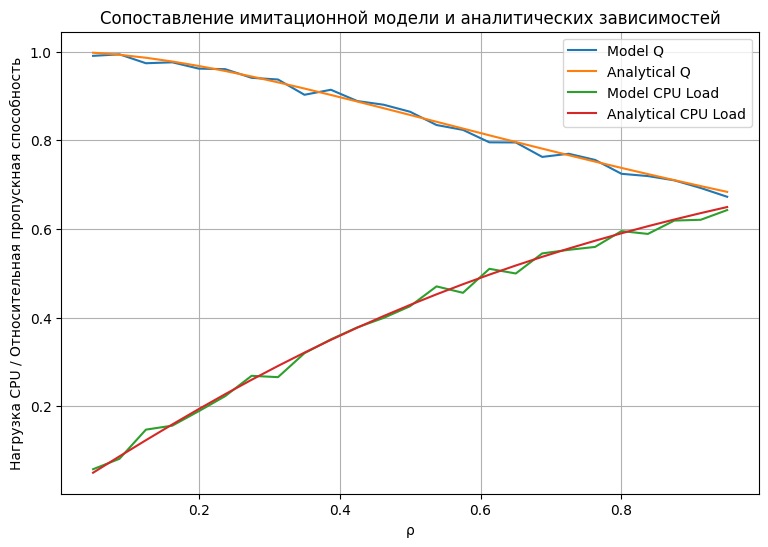

In [273]:
plt.figure(figsize=(9,6))

plt.plot(rho_values, model_Q, label="Model Q")
plt.plot(rho_values, analytical_Q, label="Analytical Q")

plt.plot(rho_values, model_load, label="Model CPU Load")
plt.plot(rho_values, analytical_load, label="Analytical CPU Load")

plt.xlabel("ρ")
plt.ylabel("Нагрузка CPU / Относительная пропускная способность")

plt.title("Сопоставление имитационной модели и аналитических зависимостей")

plt.legend()
plt.grid()

plt.show()

## Задание №5

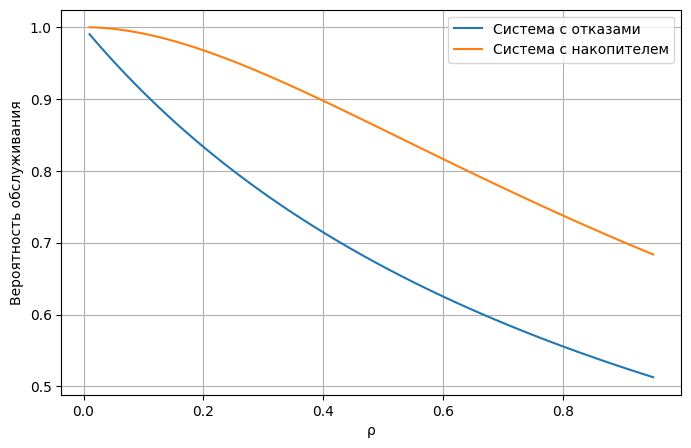

In [274]:
rho_values = np.linspace(0.01, 0.95, 100)

Q_refusal = 1 / (1 + rho_values)

Q_buffer = (1 - rho_values**2) / (1 - rho_values**3)

plt.figure(figsize=(8,5))

plt.plot(rho_values, Q_refusal, label="Система с отказами")
plt.plot(rho_values, Q_buffer, label="Система с накопителем")

plt.xlabel("ρ")
plt.ylabel("Вероятность обслуживания")

plt.legend()
plt.grid()

plt.show()

## Задание №6

In [ ]:
lambda_fixed = 0.5

c1 = 1 # прибыль от обработки одной заявки
qf = 0.15 # стоимость потери заявки при отказе
qr = 0.01 # стоимость потерь, связанная с простоем заявки в очереди

rho_values = np.linspace(0.05, 0.95, 100)

E_refusal_rho = []
E_buffer_rho = []

for rho in rho_values:
    mu = lambda_fixed / rho

    # система с отказами
    Pf_ref = rho / (1 + rho)

    E1 = (1 - Pf_ref) * lambda_fixed * c1 - qf * Pf_ref * lambda_fixed
    E_refusal_rho.append(E1)

    # система с накопителем
    P0 = 1 / (1 + rho + rho**2)
    Pf = rho**2 * P0

    tr = (rho**2 * P0) / lambda_fixed

    E2 = (1 - Pf) * lambda_fixed * c1 - qf * Pf * lambda_fixed - qr * tr
    E_buffer_rho.append(E2)

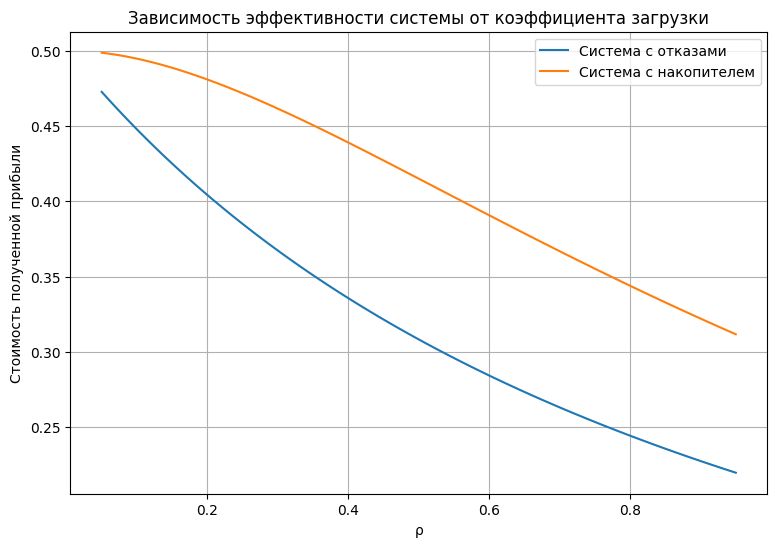

In [278]:
plt.figure(figsize=(9,6))

plt.plot(rho_values, E_refusal_rho, label="Система с отказами")
plt.plot(rho_values, E_buffer_rho, label="Система с накопителем")

plt.xlabel("ρ")
plt.ylabel("Стоимость полученной прибыли")

plt.title("Зависимость эффективности системы от коэффициента загрузки")

plt.legend()
plt.grid()

plt.show()